# Brownian Motion Analysis — From Text/CSV Positions (Batch Mode)

Batch-processes position files (Tracker TXT, MTrack2 CSV/TXT) with skip-if-up-to-date logic.
No OpenCV / no particle detection — positions are pre-tracked externally.

**Supported formats:**
- **MTrack2 CSV/TXT:** `Frame, X1, Y1, Flag1, ...` (pixels)
- **Tracker TXT:** `#multi:` header, `t, x, y, ...` (micrometers)

**Auto-parsed from filename:** bead diameter, solute %, solute type

**Per-dataset outputs:** readme.txt, summary.txt, trackresults.txt, trajectories.png, displacement_histogram.png, msd_analysis.png, msd_analysis_presentation.png/.pdf, D_comparison.png, combined_summary.png

**Post-batch:** batch_results.csv, overall_trends.png, per-date trends, lab-level comparison plots

In [30]:
# ============================================================================
# CELL 1 — CONFIGURATION & JOBS
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2 as chi2_dist
from math import sqrt, pi
from pathlib import Path
from datetime import datetime
import configparser
import re
import os
import pandas as pd

# --- Pipeline version (bump to force reprocessing of all datasets) ---
PIPELINE_VERSION = '1.1'
FORCE_REPROCESS = False
PRESENTATION_READY = True   # True = report-quality (plot_demo style)

# --- Universal constants ---
PIXEL_SIZE_DEFAULT = 0.0684   # um/px (68.4 nm/px, 100x oil)
FPS_DEFAULT = 29.0            # frames per second
TEMPERATURE_C_DEFAULT = 21.0  # Celsius
CHAMBER_DEPTH_UM = 82.5       # tape spacer chamber depth (um)
MIN_SEGMENT_LENGTH = 10       # min frames per usable segment
MAX_JUMP_UM = 1.5             # max frame-to-frame jump (um) before splitting
k_B = 1.381e-23               # Boltzmann constant (J/K)


# --- Plot style (from PRESENTATION_READY flag) ---
#   presentationReady=True  -> 80% text-width figures, 12 pt labels,
#                              markersize 5, linewidth 1.25, PDF output
#   presentationReady=False -> original large diagnostic figures
if PRESENTATION_READY:
    _W_TEXT = 6.5                          # report text width (8.5" page, 1" margins)
    _W1 = 0.80 * _W_TEXT                   # single-panel width  (5.20")
    _H1 = (2.0/3.0) * _W1                 # single-panel height (3.47")
    _W2 = _W_TEXT                          # 1x2 panel width     (6.50")
    _H2 = 3.5                             # 1x2 panel height
    _W4 = _W_TEXT                          # 2x2 grid width      (6.50")
    _H4 = _W_TEXT                          # 2x2 grid height     (6.50")
    _FS_L = 12; _FS_LG = 10; _FS_T = 12   # fontsize: label, legend, title
    _MS = 5;  _LW = 1.25; _CAP = 3        # marker, linewidth, capsize
    _SAVE_PDF = True
else:
    _W1 = 8;   _H1 = 6                    # single-panel
    _W2 = 14;  _H2 = 6                    # 1x2 panel
    _W4 = 16;  _H4 = 12                   # 2x2 grid
    _FS_L = 12; _FS_LG = 9; _FS_T = 13
    _MS = 4;  _LW = 2; _CAP = 3
    _SAVE_PDF = False

# --- Paths ---
DATA_ROOT = Path(r"D:\Documents\SFU\PHYS382-AdvancedLab\phys332w-sfu-GIT\phys332W-sfu\Lab2-Microscopy-and-Motility\Data")
FIGURES_ROOT = Path(os.getcwd()) / 'figures' / 'from_text'

# --- JOBS: (filepath, temperature_C) ---
# Bead size, solute %, and solute type are auto-parsed from filenames.
# Naming convention (underscores = decimal points):
#   Bead size:  1um, 2_1mu, 3um, 5mu
#   Glycerol:   water-{W}ul-gly-{G}ul   -> G/(W+G)*100
#   Acetone:    water-{W}ul-ace-{A}ul    -> A/(W+A)*100
#   Zero gly:   gly-0, gly-0l, gly-0ul  -> 0%

JOBS = [
    # --- Session 2026-03-05 ---
    (DATA_ROOT / '2026-03-05' / 's2c-1um-0_5p-11_5ul-water-3978_5ul-gly-1000ul-trial3-tracker.txt', 21.0),
    (DATA_ROOT / '2026-03-05' / 's1b-3um-0_5p-2_5ul-water-597_5ul-gly-0ul-trial5-tracker.txt', 21.0),
    (DATA_ROOT / '2026-03-05' / 'r14-2_1mu-0_5p-4ul-acetone-498ul-trial1-tracker.txt', 21.0),
    (DATA_ROOT / '2026-03-05' / 'r4-5mu-0_5p-10ul-water-490ul-gly-0-trial1-tracker.txt', 21.0),
    
    

    # --- Add future jobs here ---
    # (DATA_ROOT / '2026-03-12' / 'another-file-tracker.txt', 21.0),
]

print(f'Pipeline v{PIPELINE_VERSION} | {len(JOBS)} jobs')
print(f'Data root:    {DATA_ROOT}')
print(f'Figures root: {FIGURES_ROOT}')

Pipeline v1.1 | 4 jobs
Data root:    D:\Documents\SFU\PHYS382-AdvancedLab\phys332w-sfu-GIT\phys332W-sfu\Lab2-Microscopy-and-Motility\Data
Figures root: d:\Documents\SFU\PHYS382-AdvancedLab\phys332w-sfu-GIT\phys332W-sfu\Lab2-Microscopy-and-Motility\Analysis\figures\from_text


In [31]:
# ============================================================================
# CELL 2 — FUNCTION DEFINITIONS
# ============================================================================

# ---------------------------------------------------------------
# Filename parser
# ---------------------------------------------------------------
def parse_filename(filepath):
    """Parse experiment parameters from filename.

    Naming convention (underscores = decimal points):
      Bead size:  1um, 2_1mu, 3um, 5mu
      Glycerol:   water-{W}ul-gly-{G}ul   -> G/(W+G)*100
      Acetone:    water-{W}ul-ace-{A}ul    -> A/(W+A)*100
                  acetone-{V}ul            -> 100%
      Zero gly:   gly-0, gly-0l, gly-0ul  -> 0%

    Returns: (bead_diameter_um, solute_pct, solute_type)
    """
    name = Path(filepath).stem.lower()

    # Bead diameter
    bead_match = re.search(r'(\d+(?:_\d+)?)\s*(?:mu|um)', name)
    bead_um = float(bead_match.group(1).replace('_', '.')) if bead_match else None

    # Solute type + percentage
    solute_type = 'glycerol'
    solute_pct = 0.0

    if re.search(r'[-_]ace[-_]|acetone', name):
        solute_type = 'acetone'
        # water-Wul-ace-Aul
        ace_match = re.search(r'water-(\d+(?:_\d+)?)ul-ace-(\d+(?:_\d+)?)ul', name)
        if ace_match:
            w = float(ace_match.group(1).replace('_', '.'))
            a = float(ace_match.group(2).replace('_', '.'))
            solute_pct = a / (w + a) * 100
        else:
            # Pure acetone (no water component)
            pure_ace = re.search(r'acetone-(\d+(?:_\d+)?)(?:ul)?', name)
            if pure_ace:
                solute_pct = 100.0
    else:
        # Glycerol: water-Wul-gly-Gul
        gly_match = re.search(r'water-(\d+(?:_\d+)?)ul-gly-(\d+(?:_\d+)?)ul', name)
        if gly_match:
            w = float(gly_match.group(1).replace('_', '.'))
            g = float(gly_match.group(2).replace('_', '.'))
            solute_pct = g / (w + g) * 100
        elif re.search(r'gly-0(?:ul|l)?(?:\b|[-_]|$)', name):
            solute_pct = 0.0

    return bead_um, solute_pct, solute_type


# ---------------------------------------------------------------
# Format detection + data loaders
# ---------------------------------------------------------------
def detect_format(filepath):
    """Auto-detect file format from first line.
    Returns 'tracker' or 'mtrack2'."""
    with open(filepath, 'r') as f:
        first_line = f.readline().strip()
    return 'tracker' if first_line.startswith('#multi') else 'mtrack2'


def load_position_data(filepath, file_format):
    """Load position data from file.

    Returns: (data, n_frames, n_particles, fps_detected, input_units)
      data:          array [x1,y1,x2,y2,...] per frame
      n_frames:      number of time steps
      n_particles:   number of tracked objects
      fps_detected:  FPS inferred from file (None if unavailable)
      input_units:   'um' (tracker) or 'px' (MTrack2)
    """
    if file_format == 'tracker':
        return _load_tracker(filepath)
    else:
        return _load_mtrack2(filepath)


def _load_tracker(filepath):
    """Load Tracker format: #multi: header, t,x,y,x,y,... in micrometers."""
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # Skip 3 header lines: #multi:, mass names, t,x,y,...
    data_lines = lines[3:]

    rows = []
    times = []
    for line in data_lines:
        line = line.strip()
        if not line:
            continue
        parts = line.split(',')
        times.append(float(parts[0]))
        vals = []
        for p in parts[1:]:
            p = p.strip()
            vals.append(float(p) if p else np.nan)
        rows.append(vals)

    # Infer FPS from time column
    fps = None
    if len(times) >= 2:
        dt_file = times[1] - times[0]
        if dt_file > 0:
            fps = round(1.0 / dt_file, 1)

    # Pad rows to uniform width
    max_cols = max(len(r) for r in rows)
    for r in rows:
        r.extend([np.nan] * (max_cols - len(r)))

    data = np.array(rows)

    # Strip trailing all-NaN columns
    while data.shape[1] > 0 and np.all(np.isnan(data[:, -1])):
        data = data[:, :-1]

    # Ensure even number of columns (x,y pairs)
    if data.shape[1] % 2 != 0:
        data = data[:, :-1]

    return data, data.shape[0], data.shape[1] // 2, fps, 'um'


def _load_mtrack2(filepath):
    """Load MTrack2 format: Frame,X1,Y1,Flag1,X2,Y2,Flag2,... in pixels."""
    with open(filepath, 'r') as f:
        raw_lines = f.readlines()

    # Detect delimiter
    delimiter = '\t' if '\t' in raw_lines[0] else ','

    # Find first data line (skip header + "Tracks X to Y")
    skip = 0
    for i in range(min(5, len(raw_lines))):
        stripped = raw_lines[i].strip()
        if not stripped:
            skip = i + 1
            continue
        lower = stripped.lower()
        if 'frame' in lower or lower.startswith('track'):
            skip = i + 1

    data_lines = raw_lines[skip:]
    rows = []
    for line in data_lines:
        line = line.strip()
        if not line:
            continue
        parts = line.split(delimiter)

        # Column 0 = Frame (skip); then groups of 3: X, Y, Flag
        remaining = parts[1:]
        xy = []
        for j in range(0, len(remaining), 3):
            x_str = remaining[j].strip() if j < len(remaining) else ''
            y_str = remaining[j+1].strip() if j+1 < len(remaining) else ''
            # Flag at j+2 is ignored
            xy.append(float(x_str) if x_str else np.nan)
            xy.append(float(y_str) if y_str else np.nan)
        rows.append(xy)

    # Pad rows to uniform width
    max_cols = max(len(r) for r in rows)
    for r in rows:
        r.extend([np.nan] * (max_cols - len(r)))

    data = np.array(rows)
    return data, data.shape[0], data.shape[1] // 2, None, 'px'


# ---------------------------------------------------------------
# Viscosity functions (Cheng 2008 CORRECTED)
# ---------------------------------------------------------------
def get_glycerol_viscosity(glycerol_pct, temp_c):
    """Cheng (2008) CORRECTED formula for glycerol-water mixtures. Returns Pa.s."""
    T = temp_c
    eta_water = 1.790 * np.exp((-1230 - T) * T / (36100 + 360 * T))
    if glycerol_pct <= 0:
        return eta_water * 1e-3
    eta_glycerol = 12100.0 * np.exp((-1233 + T) * T / (9900 + 70 * T))
    cm = glycerol_pct / 100.0
    a = 0.705 - 0.0017 * T
    b = (4.9 + 0.036 * T) * a ** 2.5
    alpha = 1.0 - cm + (a * b * cm * (1 - cm)) / (a * cm + b * (1 - cm))
    eta_m = eta_water ** alpha * eta_glycerol ** (1 - alpha)
    return eta_m * 1e-3


def get_acetone_viscosity(acetone_vol_pct, temp_c):
    """Acetone-water mixture viscosity (Pa.s) via interpolation."""
    T = temp_c
    eta_water = 1.790 * np.exp((-1230 - T) * T / (36100 + 360 * T)) * 1e-3
    if acetone_vol_pct <= 0:
        return eta_water
    vol_pct = np.array([0, 5, 10, 15, 20, 30, 40, 50, 60, 80, 100])
    eta_mPa = np.array([0.978, 0.94, 0.90, 0.86, 0.82, 0.72, 0.62, 0.52, 0.44, 0.36, 0.32])
    eta = np.interp(acetone_vol_pct, vol_pct, eta_mPa) * 1e-3
    return eta


def get_viscosity(solute_pct, temp_c, solute_type='glycerol'):
    if solute_type == 'acetone':
        return get_acetone_viscosity(solute_pct, temp_c)
    else:
        return get_glycerol_viscosity(solute_pct, temp_c)


# ---------------------------------------------------------------
# Correction factors
# ---------------------------------------------------------------
def faxen_correction(bead_radius_m, wall_dist_m):
    """Faxen's Law parallel wall correction. Returns factor <= 1."""
    x = bead_radius_m / wall_dist_m
    return 1 - 9/16 * x + 1/8 * x**3 - 45/256 * x**4 - 1/16 * x**5


# ---------------------------------------------------------------
# Segment splitting
# ---------------------------------------------------------------
def split_tracks_at_jumps(data, min_length, max_jump):
    """Split multi-particle position data into clean segments.

    data: array with columns [x1, y1, x2, y2, ...] (NaN where missing)
    Returns list of segment dicts with 'x', 'y', 'id', 'original_particle', 'length'.
    """
    segments = []
    n_particles = data.shape[1] // 2
    segment_id = 0
    for i in range(n_particles):
        x_col = i * 2
        y_col = i * 2 + 1
        x_raw = data[:, x_col]
        y_raw = data[:, y_col]
        valid_mask = ~np.isnan(x_raw) & ~np.isnan(y_raw)
        x_clean = x_raw[valid_mask]
        y_clean = y_raw[valid_mask]
        if len(x_clean) < min_length:
            continue
        dx = np.diff(x_clean)
        dy = np.diff(y_clean)
        steps = np.sqrt(dx**2 + dy**2)
        bad_jump_indices = np.where(steps > max_jump)[0]
        if len(bad_jump_indices) == 0:
            segment_id += 1
            segments.append({'x': x_clean, 'y': y_clean, 'id': segment_id,
                             'original_particle': i + 1, 'length': len(x_clean)})
        else:
            split_indices = bad_jump_indices + 1
            x_segments = np.split(x_clean, split_indices)
            y_segments = np.split(y_clean, split_indices)
            for x_seg, y_seg in zip(x_segments, y_segments):
                if len(x_seg) >= min_length:
                    segment_id += 1
                    segments.append({'x': x_seg, 'y': y_seg, 'id': segment_id,
                                     'original_particle': i + 1, 'length': len(x_seg)})
    segments.sort(key=lambda s: s['length'], reverse=True)
    return segments


# ---------------------------------------------------------------
# Fit helpers
# ---------------------------------------------------------------
def gaussian_pdf(x, mean, std_dev):
    """Normalized Gaussian PDF (for density=True histograms)."""
    return (1.0 / (np.sqrt(2 * np.pi) * abs(std_dev))) * np.exp(-(x - mean)**2 / (2 * std_dev**2))

def sigma_clip(arr, sigma=3, max_iter=5):
    """Iterative sigma-clipping. Returns clipped array."""
    a = np.array(arr, dtype=float)
    for _ in range(max_iter):
        mu = np.mean(a)
        sd = np.std(a)
        if sd == 0:
            break
        mask = np.abs(a - mu) < sigma * sd
        if mask.all():
            break
        a = a[mask]
    return a

def linear_through_origin(t, slope):
    """MSD = slope * t  (forced through origin)."""
    return slope * t

def linear(t, slope, intercept):
    """MSD = slope * t + intercept  (kept for reference)."""
    return slope * t + intercept

def power_law(t, K, alpha):
    return K * t**alpha


print('All functions loaded.')

All functions loaded.


In [32]:
# ============================================================================
# CELL 3 — PIPELINE UTILITY FUNCTIONS
# ============================================================================
# Metadata (readme.txt), trackresults writer, version stamp.
# These enable batch processing with skip-if-up-to-date logic.

def stamp_version(fig):
    """Add a small pipeline version label to the bottom-right of a figure."""
    fig.text(0.99, 0.005, f'Tracker Pipeline v{PIPELINE_VERSION}',
             fontsize=6, color='gray', alpha=0.5, ha='right', va='bottom',
             transform=fig.transFigure)


def load_or_create_metadata(figures_dir, filepath, file_format, input_units,
                            fps, n_frames, n_particles, bead_diameter_um,
                            solute_pct, solute_type, temp_c):
    """Load or create readme.txt metadata file.

    Structure:
      [constants]  — write-once (data file properties)
      [volatile]   — overwritten every run (D values, alpha, etc.)

    Returns: (config, should_process)
    """
    readme_path = figures_dir / 'readme.txt'
    config = configparser.ConfigParser()

    if readme_path.exists():
        config.read(str(readme_path), encoding='utf-8')
        stored_version = config.get('volatile', 'pipeline_version', fallback='0.0')
        if stored_version == PIPELINE_VERSION and not FORCE_REPROCESS:
            return config, False
        print(f'    [metadata] Version mismatch ({stored_version} -> {PIPELINE_VERSION}), reprocessing')
        return config, True

    config['constants'] = {
        'filename': Path(filepath).name,
        'format': file_format.upper(),
        'input_units': input_units,
        'fps': str(fps),
        'total_frames': str(n_frames),
        'n_particles': str(n_particles),
        'bead_diameter_um': str(bead_diameter_um),
        'solute_pct': f'{solute_pct:.2f}',
        'solute_type': solute_type,
        'temp_c': str(temp_c),
        'pixel_size_um': str(PIXEL_SIZE_DEFAULT),
    }
    config['volatile'] = {}

    with open(str(readme_path), 'w', encoding='utf-8') as f:
        f.write('# === TRACKER DATA METADATA (readme.txt) ===\n')
        f.write(f'# Generated: {datetime.now().isoformat()}\n')
        f.write(f'# Pipeline: Tracker Pipeline v{PIPELINE_VERSION}\n')
        f.write('#\n')
        f.write('# [constants] — write-once (data file properties + parsed params)\n')
        f.write('# [volatile]  — overwritten every pipeline run\n\n')
        config.write(f)

    print(f'    [metadata] Created readme.txt')
    return config, True


def update_volatile_metadata(figures_dir, D_var, D_gauss, D_msd,
                             D_var_err, D_gauss_err, D_msd_err,
                             alpha, alpha_err, n_segments):
    """Update the [volatile] section of readme.txt after analysis."""
    readme_path = figures_dir / 'readme.txt'
    if not readme_path.exists():
        return

    config = configparser.ConfigParser()
    config.read(str(readme_path), encoding='utf-8')

    config['volatile'] = {
        'pipeline_version': PIPELINE_VERSION,
        'd_variance': f'{D_var:.6f}',
        'd_variance_err': f'{D_var_err:.6f}',
        'd_gauss': f'{D_gauss:.6f}',
        'd_gauss_err': f'{D_gauss_err:.6f}',
        'd_msd': f'{D_msd:.6f}',
        'd_msd_err': f'{D_msd_err:.6f}',
        'alpha': f'{alpha:.4f}',
        'alpha_err': f'{alpha_err:.4f}',
        'n_segments': str(n_segments),
        'last_processed': datetime.now().isoformat(),
    }

    with open(str(readme_path), 'w', encoding='utf-8') as f:
        f.write('# === TRACKER DATA METADATA (readme.txt) ===\n')
        f.write(f'# Last updated: {datetime.now().isoformat()}\n')
        f.write(f'# Pipeline: Tracker Pipeline v{PIPELINE_VERSION}\n')
        f.write('#\n')
        f.write('# [constants] — write-once (data file properties + parsed params)\n')
        f.write('# [volatile]  — overwritten every pipeline run\n\n')
        config.write(f)


def write_trackresults(figures_dir, segments, input_units):
    """Write position data in MTrack2-compatible tab-separated format."""
    if not segments:
        return
    out_path = figures_dir / 'trackresults.txt'
    max_len = max(seg['length'] for seg in segments)
    with open(str(out_path), 'w', encoding='utf-8') as f:
        headers = ['Frame']
        for seg in segments:
            headers.extend([f'X{seg["id"]}', f'Y{seg["id"]}', f'Flag{seg["id"]}'])
        f.write('\t'.join(headers) + '\n')
        for frame in range(max_len):
            row = [str(frame + 1)]
            for seg in segments:
                if frame < seg['length']:
                    row.extend([f'{seg["x"][frame]:.4f}', f'{seg["y"][frame]:.4f}', '0'])
                else:
                    row.extend(['', '', ''])
            f.write('\t'.join(row) + '\n')


print('Pipeline utilities loaded.')

Pipeline utilities loaded.


In [33]:
# ============================================================================
# CELL 4 — BATCH PROCESSING LOOP
# ============================================================================
# Processes all JOBS: parse → load → segment → displace → MSD → plots → summary
# Per-file plots are saved to disk (not shown inline to avoid clutter).

FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

n_total = len(JOBS)
n_processed = 0
n_skipped = 0
n_failed = 0
batch_results = []

for job_idx, (filepath, temp_c) in enumerate(JOBS, 1):
    filepath = Path(filepath)
    file_stem = filepath.stem

    print(f'\n{"="*70}')
    print(f'[{job_idx}/{n_total}] {filepath.name}')

    if not filepath.exists():
        print(f'  FILE NOT FOUND: {filepath}')
        n_failed += 1
        continue

    try:
        # --- Parse filename ---
        bead_um, solute_pct, solute_type = parse_filename(filepath)
        if bead_um is None:
            print(f'  WARNING: Could not parse bead size, defaulting to 1.0 um')
            bead_um = 1.0
        solute_label = solute_type.capitalize()

        # --- Output folder ---
        date_str = filepath.parent.name
        figures_dir = FIGURES_ROOT / date_str / file_stem
        figures_dir.mkdir(parents=True, exist_ok=True)

        # --- Detect format & load ---
        file_format = detect_format(filepath)
        raw_data, n_frames, n_particles, fps_detected, input_units = \
            load_position_data(filepath, file_format)

        pixel_size = 1.0 if input_units == 'um' else PIXEL_SIZE_DEFAULT
        fps = fps_detected if fps_detected else FPS_DEFAULT
        dt = 1.0 / fps
        pos_unit_label = r'$\mu\mathrm{m}$' if input_units == 'um' else 'pixels'
        px_label = r'$\mu\mathrm{m}$' if input_units == 'um' else 'px'

        print(f'  Format: {file_format.upper()} | Units: {input_units} | '
              f'{n_frames} frames, {n_particles} particles')
        print(f'  Parsed: {bead_um} um beads, {solute_pct:.1f}% {solute_label}, {temp_c} C')
        print(f'  FPS: {fps:.1f} {"(from file)" if fps_detected else "(default)"} | '
              f'dt = {dt*1000:.2f} ms')

        # --- Metadata check (skip if up-to-date) ---
        config, should_process = load_or_create_metadata(
            figures_dir, filepath, file_format, input_units,
            fps, n_frames, n_particles, bead_um,
            solute_pct, solute_type, temp_c)

        if not should_process:
            print(f'  SKIP (v{PIPELINE_VERSION} already processed)')
            n_skipped += 1
            try:
                viscosity = get_viscosity(solute_pct, temp_c, solute_type)
                r_m = (bead_um / 2) * 1e-6
                T_K = temp_c + 273.15
                D_theory_um = k_B * T_K / (6 * pi * viscosity * r_m) * 1e12
                h_mid = (CHAMBER_DEPTH_UM / 2) * 1e-6
                F_mid = faxen_correction(r_m, h_mid)
                batch_results.append({
                    'video': file_stem, 'date': date_str,
                    'bead_um': bead_um, 'solute_pct': solute_pct,
                    'solute_type': solute_label,
                    'eta_mPas': viscosity * 1e3, 'fps': fps,
                    'n_segments': int(config.get('volatile', 'n_segments', fallback='0')),
                    'D_variance': float(config.get('volatile', 'd_variance', fallback='0')),
                    'D_gauss': float(config.get('volatile', 'd_gauss', fallback='0')),
                    'D_msd': float(config.get('volatile', 'd_msd', fallback='0')),
                    'D_var_err': float(config.get('volatile', 'd_variance_err', fallback='0')),
                    'D_gauss_err': float(config.get('volatile', 'd_gauss_err', fallback='0')),
                    'D_msd_err': float(config.get('volatile', 'd_msd_err', fallback='0')),
                    'D_theory': D_theory_um, 'D_faxen': D_theory_um * F_mid, 'F_mid': F_mid,
                    'alpha': float(config.get('volatile', 'alpha', fallback='0')),
                    'alpha_err': float(config.get('volatile', 'alpha_err', fallback='0')),
                })
            except Exception:
                pass
            continue

        # --- Segment splitting ---
        max_jump_data = MAX_JUMP_UM / pixel_size
        segments = split_tracks_at_jumps(raw_data, MIN_SEGMENT_LENGTH, max_jump_data)

        if len(segments) == 0:
            print(f'  NO VALID SEGMENTS — skipping')
            n_failed += 1
            continue

        selected = segments
        n_to_use = len(selected)
        print(f'  Segments: {n_to_use} usable')

        # --- Viscosity & theory ---
        viscosity = get_viscosity(solute_pct, temp_c, solute_type)
        TEMPERATURE_K = temp_c + 273.15
        r_m = (bead_um / 2) * 1e-6
        D_theory = k_B * TEMPERATURE_K / (6 * pi * viscosity * r_m)
        D_theory_um = D_theory * 1e12
        h_mid = (CHAMBER_DEPTH_UM / 2) * 1e-6
        F_mid = faxen_correction(r_m, h_mid)
        D_theory_faxen = D_theory_um * F_mid

        # ==============================================================
        # DISPLACEMENT ANALYSIS
        # ==============================================================
        all_dx, all_dy = [], []
        for seg in selected:
            all_dx.extend(np.diff(seg['x']))
            all_dy.extend(np.diff(seg['y']))

        dx_px = np.array(all_dx)
        dy_px = np.array(all_dy)
        dx_um = dx_px * pixel_size
        dy_um = dy_px * pixel_size
        n_steps = len(dx_px)

        # METHOD 1: Direct Variance (sigma-clipped)
        dx_clipped = sigma_clip(dx_um, sigma=3, max_iter=5)
        dy_clipped = sigma_clip(dy_um, sigma=3, max_iter=5)
        n_clipped = (n_steps - len(dx_clipped)) + (n_steps - len(dy_clipped))
        if n_clipped > 0:
            print(f'  Sigma-clip removed {n_clipped} outlier steps '
                  f'({n_clipped/(2*n_steps)*100:.1f}%)')

        var_dx = np.var(dx_clipped)
        var_dy = np.var(dy_clipped)
        D_x_direct = var_dx / (2 * dt)
        D_y_direct = var_dy / (2 * dt)
        D_direct = (D_x_direct + D_y_direct) / 2

        # METHOD 2: Gaussian Fit
        counts_x, bin_edges_x = np.histogram(dx_clipped, bins='auto', density=True)
        bin_centers_x = (bin_edges_x[:-1] + bin_edges_x[1:]) / 2
        try:
            popt_x, _ = curve_fit(gaussian_pdf, bin_centers_x, counts_x,
                                  p0=[0, np.std(dx_clipped)])
            std_x_fit = abs(popt_x[1])
        except Exception:
            std_x_fit = np.std(dx_clipped)
            popt_x = [0, std_x_fit]

        counts_y, bin_edges_y = np.histogram(dy_clipped, bins='auto', density=True)
        bin_centers_y = (bin_edges_y[:-1] + bin_edges_y[1:]) / 2
        try:
            popt_y, _ = curve_fit(gaussian_pdf, bin_centers_y, counts_y,
                                  p0=[0, np.std(dy_clipped)])
            std_y_fit = abs(popt_y[1])
        except Exception:
            std_y_fit = np.std(dy_clipped)
            popt_y = [0, std_y_fit]

        D_x_fit = std_x_fit**2 / (2 * dt)
        D_y_fit = std_y_fit**2 / (2 * dt)
        D_fit = (D_x_fit + D_y_fit) / 2

        # Per-segment D for error bars
        seg_D_var, seg_D_gau = [], []
        for seg in selected:
            sdx = np.diff(seg['x']) * pixel_size
            sdy = np.diff(seg['y']) * pixel_size
            if len(sdx) < 5:
                continue
            sdx_c = sigma_clip(sdx, sigma=3, max_iter=3)
            sdy_c = sigma_clip(sdy, sigma=3, max_iter=3)
            seg_D_corr = (np.var(sdx_c) + np.var(sdy_c)) / (4 * dt)
            seg_D_var.append(seg_D_corr)
            seg_D_gau.append(seg_D_corr)

        if len(seg_D_var) > 1:
            D_direct_err = np.std(seg_D_var) / np.sqrt(len(seg_D_var))
            D_fit_err = np.std(seg_D_gau) / np.sqrt(len(seg_D_gau))
        else:
            D_direct_err = abs(D_direct - D_fit) / 2 if abs(D_direct - D_fit) > 0 else D_direct * 0.1
            D_fit_err = D_direct_err

        # ==============================================================
        # MSD ANALYSIS (free intercept)
        # ==============================================================
        max_lag = int(fps * 2.0)  # Max lag of 2 seconds
        lag_times = np.arange(1, max_lag + 1) * dt
        n_fit = max(3, max_lag // 4)
        n_fit_power = max_lag // 2

        all_MSDs = []
        for seg in selected:
            x = seg['x'].values if hasattr(seg['x'], 'values') else np.array(seg['x'])
            y = seg['y'].values if hasattr(seg['y'], 'values') else np.array(seg['y'])
            MSD_seg = np.zeros(max_lag)
            n_f = len(x)
            for lag in range(1, max_lag + 1):
                if n_f > lag:
                    dx_lag = x[lag:] - x[:-lag]
                    dy_lag = y[lag:] - y[:-lag]
                    r_sq = dx_lag**2 + dy_lag**2
                    MSD_seg[lag - 1] = np.mean(r_sq) if len(r_sq) > 0 else 0
            all_MSDs.append(MSD_seg)

        all_MSDs = np.array(all_MSDs)
        MSD_px = np.mean(all_MSDs, axis=0)
        MSD_err_px = np.std(all_MSDs, axis=0) / (np.sqrt(len(selected)) if len(selected) > 0 else 1)
        MSD_um = MSD_px * pixel_size**2
        MSD_err_um = MSD_err_px * pixel_size**2

        fit_times = lag_times[:n_fit]
        fit_MSD = MSD_um[:n_fit]
        fit_err = np.where(MSD_err_um[:n_fit] > 0, MSD_err_um[:n_fit], 1e-10)

        try:
            popt_msd, pcov_msd = curve_fit(linear, fit_times, fit_MSD,
                                            sigma=fit_err, absolute_sigma=True, p0=[1, 0])
            perr_msd = np.sqrt(np.diag(pcov_msd))
            slope = popt_msd[0]
            slope_err = perr_msd[0]
            intercept = popt_msd[1]
        except Exception:
            coeffs = np.polyfit(fit_times, fit_MSD, 1)
            slope = coeffs[0]
            intercept = coeffs[1]
            slope_err = 0

        D_msd = slope / 4
        D_msd_err = slope_err / 4

        # Power-law for alpha
        pl_t = lag_times[:n_fit_power]
        pl_msd = MSD_um[:n_fit_power]
        try:
            popt_pl, pcov_pl = curve_fit(power_law, pl_t, pl_msd,
                                          p0=[MSD_um[0] / lag_times[0] if lag_times[0] > 0 else 1, 1.0])
            K_fit = popt_pl[0]
            alpha_fit = popt_pl[1]
            alpha_err = np.sqrt(np.diag(pcov_pl))[1]
        except Exception:
            K_fit = MSD_um[0] / lag_times[0] if lag_times[0] > 0 else 1
            alpha_fit = 1.0
            alpha_err = 0

        if alpha_fit < 0.9:
            motion_type = 'Sub-diffusive'
        elif alpha_fit > 1.1:
            motion_type = 'Super-diffusive'
        else:
            motion_type = 'Normal diffusion'

        print(f'  D_var={D_direct:.4f}  D_gau={D_fit:.4f}  D_msd={D_msd:.4f}  '
              f'D_theory={D_theory_faxen:.4f}  alpha={alpha_fit:.3f} ({motion_type})')

        # ==============================================================
        # SAVE OUTPUTS (plots saved to disk, not shown inline)
        # ==============================================================
        write_trackresults(figures_dir, selected, input_units)
        colors_traj = plt.cm.tab10(np.linspace(0, 1, n_to_use))

        # --- Trajectories ---
        fig_traj, axes_traj = plt.subplots(1, 2, figsize=(_W2, _H2))
        ax = axes_traj[0]
        for seg, c in zip(selected, colors_traj):
            ax.plot(seg['x'], seg['y'], '-', linewidth=_LW, color=c, alpha=0.7)
            ax.plot(seg['x'][0], seg['y'][0], 'o', color=c, markersize=_MS)
            ax.plot(seg['x'][-1], seg['y'][-1], 's', color=c, markersize=_MS)
        ax.set_xlabel(f'$X$ ({pos_unit_label})', fontsize=_FS_L)
        ax.set_ylabel(f'$Y$ ({pos_unit_label})', fontsize=_FS_L)
        ax.set_title(f'{n_to_use} Trajectories', fontsize=_FS_T)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
        ax = axes_traj[1]
        for seg, c in zip(selected, colors_traj):
            ax.plot((seg['x'] - seg['x'][0]) * pixel_size,
                    (seg['y'] - seg['y'][0]) * pixel_size,
                    '-o', markersize=1, linewidth=1, color=c, alpha=0.7)
        ax.set_xlabel(r'$\Delta X$ ($\mu\mathrm{m}$)', fontsize=_FS_L)
        ax.set_ylabel(r'$\Delta Y$ ($\mu\mathrm{m}$)', fontsize=_FS_L)
        ax.set_title(f'Displacement from Start ({PIXEL_SIZE_DEFAULT*1000:.1f} nm/px)', fontsize=_FS_T)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
        plt.tight_layout(); stamp_version(fig_traj)
        fig_traj.savefig(str(figures_dir / 'trajectories.png'), dpi=300, bbox_inches='tight')
        if _SAVE_PDF:
            fig_traj.savefig(str(figures_dir / 'trajectories.pdf'), bbox_inches='tight')
        plt.close(fig_traj)

        # --- Displacement histogram ---
        fig_hist, axes_hist = plt.subplots(1, 2, figsize=(_W2, _H2))
        bw_x = bin_edges_x[1] - bin_edges_x[0]
        ax = axes_hist[0]
        ax.bar(bin_centers_x, counts_x, width=bw_x, alpha=0.6, color='steelblue', label='Data (density)')
        x_fine = np.linspace(bin_centers_x[0], bin_centers_x[-1], 200)
        ax.plot(x_fine, gaussian_pdf(x_fine, *popt_x), 'r-', linewidth=_LW,
                label=f'Gaussian PDF fit\n$\\sigma$ = {std_x_fit:.4f}' + r' $\mu\mathrm{m}$')
        ax.set_xlabel(r'$\Delta x$ per frame ($\mu\mathrm{m}$)', fontsize=_FS_L)
        ax.set_ylabel(r'Probability Density', fontsize=_FS_L)
        ax.set_title(r'$X$ Displacement $-$ $D_x$ = ' + f'{D_x_fit:.4f}' + r' $\mu\mathrm{m}^2/\mathrm{s}$', fontsize=_FS_T)
        ax.legend(fontsize=_FS_LG); ax.grid(True, alpha=0.3)
        bw_y = bin_edges_y[1] - bin_edges_y[0]
        ax = axes_hist[1]
        ax.bar(bin_centers_y, counts_y, width=bw_y, alpha=0.6, color='darkorange', label='Data (density)')
        y_fine = np.linspace(bin_centers_y[0], bin_centers_y[-1], 200)
        ax.plot(y_fine, gaussian_pdf(y_fine, *popt_y), 'r-', linewidth=_LW,
                label=f'Gaussian PDF fit\n$\\sigma$ = {std_y_fit:.4f}' + r' $\mu\mathrm{m}$')
        ax.set_xlabel(r'$\Delta y$ per frame ($\mu\mathrm{m}$)', fontsize=_FS_L)
        ax.set_ylabel(r'Probability Density', fontsize=_FS_L)
        ax.set_title(r'$Y$ Displacement $-$ $D_y$ = ' + f'{D_y_fit:.4f}' + r' $\mu\mathrm{m}^2/\mathrm{s}$', fontsize=_FS_T)
        ax.legend(fontsize=_FS_LG); ax.grid(True, alpha=0.3)
        plt.tight_layout(); stamp_version(fig_hist)
        fig_hist.savefig(str(figures_dir / 'displacement_histogram.png'), dpi=300, bbox_inches='tight')
        if _SAVE_PDF:
            fig_hist.savefig(str(figures_dir / 'displacement_histogram.pdf'), bbox_inches='tight')
        plt.close(fig_hist)

        # --- MSD analysis (full-size) ---
        fig_msd, axes_msd = plt.subplots(1, 2, figsize=(_W2, _H2))
        fit_line_t = np.linspace(0, lag_times[n_fit-1], 100)
        pl_line_t = np.linspace(dt, lag_times[n_fit_power-1], 100)
        valid = MSD_um > 0
        ref_t = np.logspace(np.log10(dt), np.log10(lag_times[-1]), 50)
        msd_at_1 = MSD_um[0] if MSD_um[0] > 0 else 1e-6
        ax = axes_msd[0]
        ax.errorbar(lag_times, MSD_um, yerr=MSD_err_um, fmt='o',
                    markersize=_MS, capsize=_CAP, alpha=0.6, color='steelblue', label='MSD data', zorder=3)
        ax.plot(fit_line_t, linear(fit_line_t, slope, intercept), 'r-', linewidth=_LW,
                label=r'Linear fit: $D$ = ' + f'{D_msd:.4f}' + r' $\pm$ ' + f'{D_msd_err:.4f}' + r' $\mu\mathrm{m}^2/\mathrm{s}$')
        ax.plot(pl_line_t, power_law(pl_line_t, K_fit, alpha_fit), 'g--', linewidth=_LW,
                label=r'Power law: $\alpha$ = ' + f'{alpha_fit:.2f}')
        ax.set_xlabel(r'Lag time $\tau$ (s)', fontsize=_FS_L)
        ax.set_ylabel(r'MSD ($\mu\mathrm{m}^2$)', fontsize=_FS_L)
        ax.set_title(r'MSD $-$ Linear Scale', fontsize=_FS_T); ax.legend(fontsize=_FS_LG); ax.grid(True, alpha=0.3)
        ax = axes_msd[1]
        ax.errorbar(lag_times[valid], MSD_um[valid], yerr=MSD_err_um[valid],
                    fmt='o', markersize=_MS, capsize=_CAP, alpha=0.6, color='steelblue', label='MSD data', zorder=3)
        ax.plot(ref_t, msd_at_1 * (ref_t/dt)**1, 'k:', alpha=0.4, linewidth=_LW, label=r'$\alpha=1$ (diffusive)')
        ax.plot(ref_t, msd_at_1 * (ref_t/dt)**2, 'k--', alpha=0.4, linewidth=_LW, label=r'$\alpha=2$ (ballistic)')
        ax.plot(pl_line_t, power_law(pl_line_t, K_fit, alpha_fit), 'g-', linewidth=_LW,
                label=r'Fit: $\alpha$ = ' + f'{alpha_fit:.2f}' + r' $\pm$ ' + f'{alpha_err:.2f}')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(r'Lag time $\tau$ (s)', fontsize=_FS_L)
        ax.set_ylabel(r'MSD ($\mu\mathrm{m}^2$)', fontsize=_FS_L)
        ax.set_title(r'MSD $-$ Log-Log Scale', fontsize=_FS_T); ax.legend(fontsize=_FS_LG); ax.grid(True, alpha=0.3, which='both')
        plt.tight_layout(); stamp_version(fig_msd)
        fig_msd.savefig(str(figures_dir / 'msd_analysis.png'), dpi=300, bbox_inches='tight')
        if _SAVE_PDF:
            fig_msd.savefig(str(figures_dir / 'msd_analysis.pdf'), bbox_inches='tight')
        plt.close(fig_msd)

        # --- Presentation MSD (smaller, frameless) ---
        fig_pres, axes_pres = plt.subplots(1, 2, figsize=(_W2, _H2))
        for spine in ['top', 'right']:
            for ax_p in axes_pres:
                ax_p.spines[spine].set_visible(False)
        ax = axes_pres[0]
        ax.errorbar(lag_times, MSD_um, yerr=MSD_err_um, fmt='o', markersize=_MS, capsize=_CAP, alpha=0.6, color='steelblue', label='MSD data', zorder=3)
        ax.plot(fit_line_t, linear(fit_line_t, slope, intercept), 'r-', linewidth=_LW,
                label=r'Linear fit: $D$ = ' + f'{D_msd:.4f}' + r' $\pm$ ' + f'{D_msd_err:.4f}' + r' $\mu\mathrm{m}^2/\mathrm{s}$')
        ax.plot(pl_line_t, power_law(pl_line_t, K_fit, alpha_fit), 'g--', linewidth=_LW,
                label=r'Power law: $\alpha$ = ' + f'{alpha_fit:.2f}')
        ax.set_xlabel(r'Lag time $\tau$ (s)', fontsize=_FS_L); ax.set_ylabel(r'MSD ($\mu\mathrm{m}^2$)', fontsize=_FS_L)
        ax.set_title(r'MSD $-$ Linear Scale', fontsize=_FS_T); ax.legend(fontsize=_FS_LG, frameon=False)
        ax = axes_pres[1]
        ax.errorbar(lag_times[valid], MSD_um[valid], yerr=MSD_err_um[valid],
                    fmt='o', markersize=_MS, capsize=_CAP, alpha=0.6, color='steelblue', label='MSD data', zorder=3)
        ax.plot(ref_t, msd_at_1 * (ref_t/dt)**1, 'k:', alpha=0.4, linewidth=_LW, label=r'$\alpha=1$ (diffusive)')
        ax.plot(ref_t, msd_at_1 * (ref_t/dt)**2, 'k--', alpha=0.4, linewidth=_LW, label=r'$\alpha=2$ (ballistic)')
        ax.plot(pl_line_t, power_law(pl_line_t, K_fit, alpha_fit), 'g-', linewidth=_LW,
                label=r'Fit: $\alpha$ = ' + f'{alpha_fit:.2f}' + r' $\pm$ ' + f'{alpha_err:.2f}')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(r'Lag time $\tau$ (s)', fontsize=_FS_L); ax.set_ylabel(r'MSD ($\mu\mathrm{m}^2$)', fontsize=_FS_L)
        ax.set_title(r'MSD $-$ Log-Log Scale', fontsize=_FS_T); ax.legend(fontsize=_FS_LG, frameon=False)
        plt.tight_layout(); stamp_version(fig_pres)
        fig_pres.savefig(str(figures_dir / 'msd_analysis_presentation.png'), dpi=300, bbox_inches='tight')
        fig_pres.savefig(str(figures_dir / 'msd_analysis_presentation.pdf'), bbox_inches='tight')
        plt.close(fig_pres)

        # --- D comparison ---
        fig_dcomp, ax_dc = plt.subplots(figsize=(_W1, _H1))
        methods = ['Direct\nVariance', 'Gaussian\nFit', 'MSD\nSlope', 'Stokes-Einstein\n(+Faxen)']
        D_vals = [D_direct, D_fit, D_msd, D_theory_faxen]
        D_errs = [D_direct_err, D_fit_err, D_msd_err, 0]
        bar_colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
        bars = ax_dc.bar(methods, D_vals, yerr=D_errs, capsize=_CAP,
                         color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        for bar, val in zip(bars, D_vals):
            ax_dc.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(D_vals) * 0.02,
                       f'{val:.4f}', ha='center', va='bottom', fontsize=9)
        ax_dc.set_ylabel(r'Diffusion Coefficient $D$ ($\mu\mathrm{m}^2/\mathrm{s}$)', fontsize=_FS_L)
        ax_dc.set_title(f'{bead_um}' + r' $\mu\mathrm{m}$ beads $-$ ' + f'{solute_pct:.1f}% {solute_label} $-$ '
                        f'{PIXEL_SIZE_DEFAULT*1000:.1f} nm/px $-$ {fps:.0f} fps', fontsize=_FS_T)
        ax_dc.grid(True, alpha=0.3, axis='y'); ax_dc.set_ylim(0, max(D_vals) * 1.3)
        plt.tight_layout(); stamp_version(fig_dcomp)
        fig_dcomp.savefig(str(figures_dir / 'D_comparison.png'), dpi=300, bbox_inches='tight')
        if _SAVE_PDF:
            fig_dcomp.savefig(str(figures_dir / 'D_comparison.pdf'), bbox_inches='tight')
        plt.close(fig_dcomp)

        # --- Combined summary (2x3) ---
        _suptitle = (f'{bead_um} um beads | {solute_pct:.1f}% {solute_label} | '
                     f'{temp_c}C | {fps:.0f} fps | {file_format.upper()}')
        fig_comb, axes_comb = plt.subplots(2, 3, figsize=(24, 14) if not PRESENTATION_READY else (12, 8))
        ax = axes_comb[0, 0]
        for i in range(n_particles):
            xr = raw_data[:, i*2]; yr = raw_data[:, i*2 + 1]
            v = ~np.isnan(xr) & ~np.isnan(yr)
            if np.sum(v) > 0: ax.plot(xr[v], yr[v], '.', markersize=1, alpha=0.3)
        ax.set_xlabel(f'X ({px_label})'); ax.set_ylabel(f'Y ({px_label})')
        ax.set_title(f'All positions ({n_particles} particles, {n_frames} frames)')
        ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
        ax = axes_comb[0, 1]
        for seg, c in zip(selected, colors_traj):
            ax.plot(seg['x'], seg['y'], '-', linewidth=1, color=c, alpha=0.7)
            ax.plot(seg['x'][0], seg['y'][0], 'o', color=c, markersize=3)
        ax.set_xlabel(f'X ({px_label})'); ax.set_ylabel(f'Y ({px_label})')
        ax.set_title(f'{n_to_use} Trajectories ({px_label})')
        ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
        ax = axes_comb[0, 2]
        for seg, c in zip(selected, colors_traj):
            ax.plot((seg['x'] - seg['x'][0]) * pixel_size,
                    (seg['y'] - seg['y'][0]) * pixel_size,
                    '-o', markersize=1, linewidth=1, color=c, alpha=0.7)
        ax.set_xlabel(r'$\Delta X$ ($\mu$m)'); ax.set_ylabel(r'$\Delta Y$ ($\mu$m)')
        ax.set_title('Displacement from Start'); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
        ax = axes_comb[1, 0]
        ax.bar(bin_centers_x, counts_x, width=bw_x, alpha=0.6, color='steelblue', label='Data')
        ax.plot(np.linspace(bin_centers_x[0], bin_centers_x[-1], 200),
                gaussian_pdf(np.linspace(bin_centers_x[0], bin_centers_x[-1], 200), *popt_x),
                'r-', linewidth=2, label=f'$\\sigma$={std_x_fit:.4f} $\\mu$m')
        ax.set_xlabel(r'$\Delta x$ per frame ($\mu\mathrm{m}$)', fontsize=_FS_L)
        ax.set_ylabel(r'Probability Density', fontsize=_FS_L)
        ax.set_title(r'$X$ Displacement Histogram', fontsize=_FS_T); ax.legend(fontsize=_FS_LG); ax.grid(True, alpha=0.3)
        ax = axes_comb[1, 1]
        ax.errorbar(lag_times, MSD_um, yerr=MSD_err_um, fmt='o', markersize=3, capsize=2, alpha=0.6, color='steelblue')
        ax.plot(np.linspace(0, lag_times[n_fit-1], 100),
                linear(np.linspace(0, lag_times[n_fit-1], 100), slope, intercept),
                'r-', linewidth=2, label=f'D={D_msd:.4f} $\\mu$m$^2$/s')
        ax.plot(np.linspace(dt, lag_times[n_fit_power-1], 100),
                power_law(np.linspace(dt, lag_times[n_fit_power-1], 100), K_fit, alpha_fit),
                'g--', linewidth=2, label=f'$\\alpha$={alpha_fit:.2f}')
        ax.set_xlabel(r'$\tau$ (s)', fontsize=_FS_L); ax.set_ylabel(r'MSD ($\mu\mathrm{m}^2$)', fontsize=_FS_L)
        ax.set_title('MSD Analysis', fontsize=_FS_T); ax.legend(fontsize=_FS_LG); ax.grid(True, alpha=0.3)
        ax = axes_comb[1, 2]
        methods_short = ['D_var', 'D_gauss', 'D_msd', 'Theory']
        D_vals_c = [D_direct, D_fit, D_msd, D_theory_faxen]
        D_errs_c = [D_direct_err, D_fit_err, D_msd_err, 0]
        bars_c = ax.bar(methods_short, D_vals_c, yerr=D_errs_c, capsize=4,
                        color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        for bar, val in zip(bars_c, D_vals_c):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(D_vals_c)*0.02,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=8)
        ax.set_ylabel(r'$D$ ($\mu\mathrm{m}^2/\mathrm{s}$)', fontsize=_FS_L); ax.set_title(r'$D$ Comparison', fontsize=_FS_T)
        ax.grid(True, alpha=0.3, axis='y'); ax.set_ylim(0, max(D_vals_c) * 1.35)
        fig_comb.suptitle(_suptitle, fontsize=_FS_T + 2, fontweight='bold')
        plt.tight_layout(); stamp_version(fig_comb)
        fig_comb.savefig(str(figures_dir / 'combined_summary.png'), dpi=200, bbox_inches='tight')
        plt.close(fig_comb)

        # --- Text summary ---
        summary_lines = []
        summary_lines.append('=' * 70)
        summary_lines.append('ANALYSIS SUMMARY (from text positions)')
        summary_lines.append('=' * 70)
        summary_lines.append(f'')
        summary_lines.append(f'Input file: {filepath}')
        summary_lines.append(f'Format: {file_format.upper()} | Input units: {input_units}')
        summary_lines.append(f'Bead diameter: {bead_um} um (parsed from filename)')
        summary_lines.append(f'Solute: {solute_pct:.1f}% {solute_label} (parsed from filename)')
        summary_lines.append(f'Temperature: {temp_c} C ({TEMPERATURE_K:.2f} K)')
        summary_lines.append(f'Viscosity: {viscosity*1e3:.3f} mPa.s ({viscosity:.6f} Pa.s)')
        summary_lines.append(f'Pixel size: {PIXEL_SIZE_DEFAULT} um/px ({PIXEL_SIZE_DEFAULT*1000:.1f} nm/px)')
        summary_lines.append(f'Frame rate: {fps} fps {"(from file)" if fps_detected else "(default)"}')
        summary_lines.append(f'dt: {dt*1000:.2f} ms')
        summary_lines.append(f'')
        summary_lines.append(f'Data:')
        summary_lines.append(f'  Total frames: {n_frames}')
        summary_lines.append(f'  Particles: {n_particles}')
        summary_lines.append(f'  Segments used: {n_to_use}')
        summary_lines.append(f'  Total displacement steps: {n_steps}')
        summary_lines.append(f'')
        summary_lines.append(f'Diffusion Coefficients (um^2/s):')
        summary_lines.append(f'  Method 1 (Direct Variance): {D_direct:.4f} +/- {D_direct_err:.4f}')
        summary_lines.append(f'  Method 2 (Gaussian Fit):     {D_fit:.4f} +/- {D_fit_err:.4f}')
        summary_lines.append(f'  Method 3 (MSD Slope):        {D_msd:.4f} +/- {D_msd_err:.4f}')
        summary_lines.append(f'')
        summary_lines.append(f'Theory (Stokes-Einstein):')
        summary_lines.append(f'  D_0 (base):      {D_theory_um:.4f} um^2/s')
        summary_lines.append(f'  Faxen factor:     {F_mid:.4f} (midplane, h={CHAMBER_DEPTH_UM/2:.1f} um)')
        summary_lines.append(f'  D_theory (final): {D_theory_faxen:.4f} um^2/s')
        summary_lines.append(f'')
        summary_lines.append(f'Deviations from Theory (S-E + Faxen):')
        for name, D_val in [('Direct Variance', D_direct),
                             ('Gaussian Fit', D_fit), ('MSD Slope', D_msd)]:
            dev = (D_val - D_theory_faxen) / D_theory_faxen * 100
            summary_lines.append(f'  {name}: {dev:+.1f}%')
        summary_lines.append(f'')
        summary_lines.append(f'MSD Exponent:')
        summary_lines.append(f'  alpha = {alpha_fit:.3f} +/- {alpha_err:.3f}')
        summary_lines.append(f'  Classification: {motion_type}')
        summary_lines.append(f'')
        summary_lines.append(f'Figures saved to: {figures_dir}')
        summary_lines.append('=' * 70)
        with open(str(figures_dir / 'summary.txt'), 'w', encoding='utf-8') as f:
            f.write('\n'.join(summary_lines))

        # Update metadata
        update_volatile_metadata(figures_dir, D_direct, D_fit, D_msd,
                                 D_direct_err, D_fit_err, D_msd_err,
                                 alpha_fit, alpha_err, n_to_use)

        print(f'  DONE. Saved to: {figures_dir}')

        # Collect for batch
        D_avg = np.mean([D_direct, D_fit, D_msd])
        dev_pct = (D_avg - D_theory_faxen) / D_theory_faxen * 100
        batch_results.append({
            'video': file_stem, 'date': date_str,
            'bead_um': bead_um, 'solute_pct': solute_pct,
            'solute_type': solute_label,
            'eta_mPas': viscosity * 1e3, 'fps': fps,
            'n_segments': n_to_use,
            'D_variance': D_direct, 'D_gauss': D_fit, 'D_msd': D_msd,
            'D_var_err': D_direct_err, 'D_gauss_err': D_fit_err, 'D_msd_err': D_msd_err,
            'D_theory': D_theory_um, 'D_faxen': D_theory_faxen, 'F_mid': F_mid,
            'alpha': alpha_fit, 'alpha_err': alpha_err, 'dev_pct': dev_pct,
        })
        n_processed += 1

    except Exception as e:
        import traceback
        print(f'  FAILED: {e}')
        traceback.print_exc()
        n_failed += 1

print(f'\n{"="*70}')
print(f'BATCH COMPLETE: {n_processed} processed, {n_skipped} skipped, {n_failed} failed (of {n_total} total)')
print(f'{"="*70}')


[1/4] s2c-1um-0_5p-11_5ul-water-3978_5ul-gly-1000ul-trial3-tracker.txt
  Format: TRACKER | Units: um | 120 frames, 3 particles
  Parsed: 1.0 um beads, 20.1% Glycerol, 21.0 C
  FPS: 29.0 (from file) | dt = 34.48 ms
  SKIP (v1.1 already processed)

[2/4] s1b-3um-0_5p-2_5ul-water-597_5ul-gly-0ul-trial5-tracker.txt
  Format: TRACKER | Units: um | 120 frames, 4 particles
  Parsed: 3.0 um beads, 0.0% Glycerol, 21.0 C
  FPS: 29.0 (from file) | dt = 34.48 ms
  SKIP (v1.1 already processed)

[3/4] r14-2_1mu-0_5p-4ul-acetone-498ul-trial1-tracker.txt
  Format: TRACKER | Units: um | 240 frames, 5 particles
  Parsed: 2.1 um beads, 100.0% Acetone, 21.0 C
  FPS: 29.0 (from file) | dt = 34.48 ms
    [metadata] Created readme.txt
  Segments: 5 usable
  Sigma-clip removed 19 outlier steps (0.8%)
  D_var=0.3036  D_gau=0.2999  D_msd=0.3061  D_theory=0.6322  alpha=0.942 (Normal diffusion)
  DONE. Saved to: d:\Documents\SFU\PHYS382-AdvancedLab\phys332w-sfu-GIT\phys332W-sfu\Lab2-Microscopy-and-Motility\Anal

In [34]:
# ============================================================================
# CELL 5 — BATCH RESULTS TABLE & CSV EXPORT
# ============================================================================

if batch_results:
    print(f'\n{"="*140}')
    print(f'{"BATCH RESULTS -- Pipeline v" + PIPELINE_VERSION:^140}')
    print(f'{"="*140}')
    print(f'{"Video":<50} {"Bead":>4} {"Solute":>10} {"eta":>8} {"fps":>5} '
          f'{"D_var":>8} {"D_gau":>8} {"D_msd":>8} {"D_SE+F":>8} {"Dev%":>7} {"alpha":>6}')
    print(f'{"":<50} {"(um)":>4} {"":>10} {"mPa.s":>8} {"":>5} '
          f'{"um2/s":>8} {"um2/s":>8} {"um2/s":>8} {"um2/s":>8} {"":>7} {"":>6}')
    print(f'{"-"*140}')
    for r in batch_results:
        D_avg = np.mean([r['D_variance'], r['D_gauss'], r['D_msd']])
        dev = (D_avg - r['D_faxen']) / r['D_faxen'] * 100 if r['D_faxen'] > 0 else 0
        sol = (f"{r['solute_pct']:.0f}%{r['solute_type'][:3]}"
               if r['solute_pct'] > 0 else "Water")
        name = r['video']
        if len(name) > 48:
            name = name[:45] + '...'
        print(f'{name:<50} {r["bead_um"]:>4.1f} {sol:>10} {r["eta_mPas"]:>8.3f} '
              f'{r["fps"]:>5.0f} {r["D_variance"]:>8.4f} {r["D_gauss"]:>8.4f} '
              f'{r["D_msd"]:>8.4f} {r["D_faxen"]:>8.4f} {dev:>+7.1f} {r["alpha"]:>6.2f}')
    print(f'{"="*140}')

    # CSV export
    csv_path = FIGURES_ROOT / 'batch_results.csv'
    df = pd.DataFrame(batch_results)
    col_order = ['video', 'date', 'bead_um', 'solute_pct', 'solute_type',
                  'eta_mPas', 'fps', 'n_segments',
                  'D_variance', 'D_var_err', 'D_gauss', 'D_gauss_err',
                  'D_msd', 'D_msd_err', 'D_theory', 'D_faxen', 'F_mid',
                  'alpha', 'alpha_err', 'dev_pct']
    df = df[[c for c in col_order if c in df.columns]]
    df.to_csv(str(csv_path), index=False, float_format='%.6f')
    print(f'\nSaved: {csv_path}')
else:
    print('No results to summarize.')


                                                       BATCH RESULTS -- Pipeline v1.1                                                       
Video                                              Bead     Solute      eta   fps    D_var    D_gau    D_msd   D_SE+F    Dev%  alpha
                                                   (um)               mPa.s          um2/s    um2/s    um2/s    um2/s               
--------------------------------------------------------------------------------------------------------------------------------------------
s2c-1um-0_5p-11_5ul-water-3978_5ul-gly-1000ul...    1.0     20%Gly    1.699    29   0.2073   0.2062   0.2966   0.2520    -6.1   1.06
s1b-3um-0_5p-2_5ul-water-597_5ul-gly-0ul-tria...    3.0      Water    0.981    29   0.0257   0.0247   0.0033   0.1435   -87.5   0.22
r14-2_1mu-0_5p-4ul-acetone-498ul-trial1-tracker     2.1    100%Ace    0.320    29   0.3036   0.2999   0.3061   0.6322   -52.0   0.94
r4-5mu-0_5p-10ul-water-490ul-gly-0-trial1-tra...    

Loaded 4 datasets for trend plots.


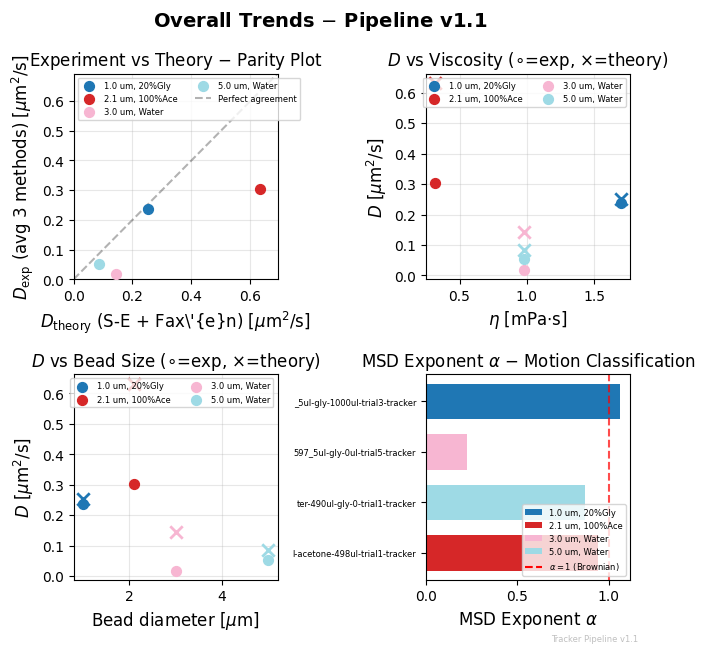

Saved: d:\Documents\SFU\PHYS382-AdvancedLab\phys332w-sfu-GIT\phys332W-sfu\Lab2-Microscopy-and-Motility\Analysis\figures\from_text\overall_trends.png


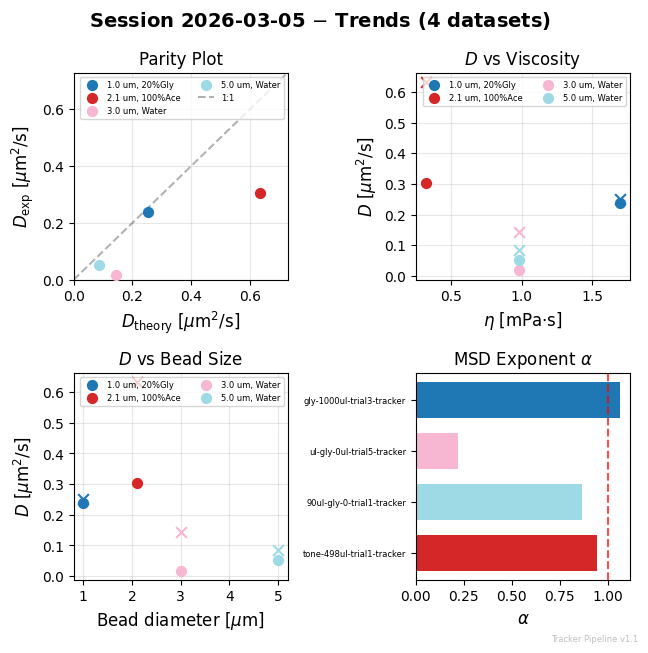

  Saved: d:\Documents\SFU\PHYS382-AdvancedLab\phys332w-sfu-GIT\phys332W-sfu\Lab2-Microscopy-and-Motility\Analysis\figures\from_text\2026-03-05\trends_2026-03-05.png


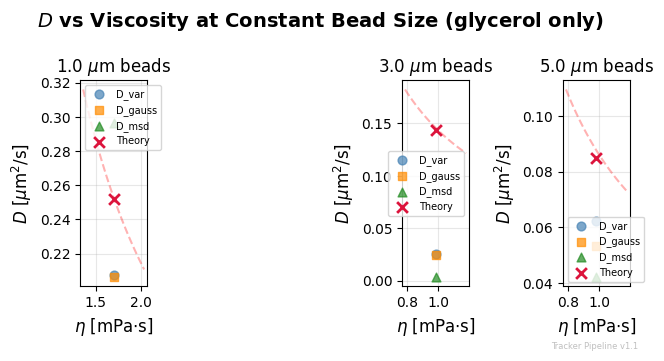

Saved: D_vs_viscosity_by_bead.png


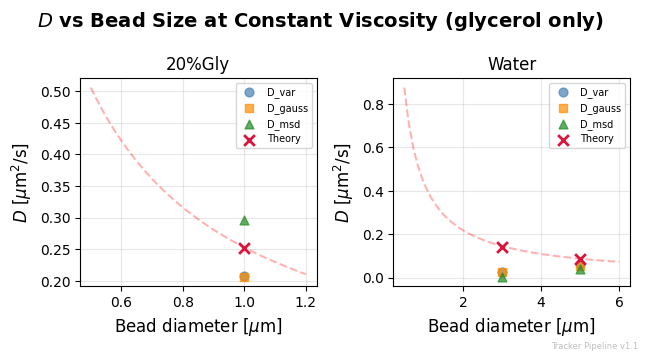

Saved: D_vs_bead_by_viscosity.png

Pipeline v1.1 complete.


In [35]:
# ============================================================================
# CELL 6 — TREND PLOTS (overall, per-date, lab-level)
# ============================================================================
# Scans ALL summary.txt files (not just current batch) so trends accumulate.

all_results = []
for summary_path in sorted(FIGURES_ROOT.rglob('summary.txt')):
    folder = summary_path.parent
    try:
        txt = summary_path.read_text(encoding='utf-8')
    except UnicodeDecodeError:
        txt = summary_path.read_text(encoding='latin-1')

    def _grab(pattern, default=None):
        m = re.search(pattern, txt)
        return m.group(1) if m else default

    video_name = folder.name
    date_str_t = folder.parent.name

    bead_str = _grab(r'Bead diameter:\s*([\d.]+)')
    solute_str = _grab(r'Solute:\s*([\d.]+)%')
    solute_type_s = 'acetone' if 'Acetone' in txt else 'glycerol'
    eta_str = _grab(r'Viscosity:\s*([\d.]+)\s*mPa')
    fps_str = _grab(r'Frame rate:\s*([\d.]+)')
    d_var_str = _grab(r'Direct Variance\):\s*([\d.eE+-]+)')
    d_gau_str = _grab(r'Gaussian Fit\):\s*([\d.eE+-]+)')
    d_msd_str = _grab(r'MSD Slope\):\s*([\d.eE+-]+)')
    d_the_str = _grab(r'D_theory \(final\):\s*([\d.eE+-]+)')
    alpha_str = _grab(r'alpha\s*=\s*([\d.eE+-]+)')

    if not all([bead_str, eta_str, d_var_str, d_msd_str, d_the_str, alpha_str]):
        continue

    bead = float(bead_str); eta = float(eta_str)
    fps_t = float(fps_str) if fps_str else 29.0
    d_var = float(d_var_str)
    d_gau = float(d_gau_str) if d_gau_str else 0.0
    d_msd = float(d_msd_str); d_the = float(d_the_str)
    alpha_v = float(alpha_str)
    solute_pct_v = float(solute_str) if solute_str else 0.0

    if solute_type_s == 'acetone':
        sol_label = f'{solute_pct_v:.0f}%Ace'
    elif solute_pct_v > 0:
        sol_label = f'{solute_pct_v:.0f}%Gly'
    else:
        sol_label = 'Water'

    d_avg = np.mean([d_var, d_gau, d_msd])
    dev_pct_v = (d_avg - d_the) / d_the * 100 if d_the > 0 else 0

    all_results.append({
        'video': video_name, 'date': date_str_t, 'bead': bead,
        'solute_pct': solute_pct_v, 'solute_type': solute_type_s,
        'solute_label': sol_label, 'eta': eta, 'fps': fps_t,
        'd_var': d_var, 'd_gau': d_gau, 'd_msd': d_msd,
        'd_theory': d_the, 'd_avg': d_avg, 'dev_pct': dev_pct_v,
        'alpha': alpha_v,
    })

print(f'Loaded {len(all_results)} datasets for trend plots.')

if len(all_results) < 2:
    print('Need >= 2 datasets for trend plots.')
else:
    def condition_key(r):
        return (r['bead'], r['solute_label'])

    unique_conditions = sorted(set(condition_key(r) for r in all_results))
    cmap = plt.cm.tab20
    cond_colors = {c: cmap(i / max(len(unique_conditions) - 1, 1))
                   for i, c in enumerate(unique_conditions)}
    cond_labels = {c: f'{c[0]} um, {c[1]}' for c in unique_conditions}

    # ---- Overall trends (2x2) ----
    fig, axes = plt.subplots(2, 2, figsize=(_W4, _H4))
    fig.suptitle(f'Overall Trends $-$ Pipeline v{PIPELINE_VERSION}', fontsize=_FS_T + 2, weight='bold')

    ax = axes[0, 0]
    for cond in unique_conditions:
        pts = [r for r in all_results if condition_key(r) == cond]
        ax.scatter([r['d_theory'] for r in pts], [r['d_avg'] for r in pts],
                   color=cond_colors[cond], s=50, label=cond_labels[cond], zorder=3)
    lim = max(ax.get_xlim()[1], ax.get_ylim()[1]) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='Perfect agreement')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(r'$D_{\mathrm{theory}}$ (S-E + Fax\'{e}n) [$\mu\mathrm{m}^2/\mathrm{s}$]', fontsize=_FS_L)
    ax.set_ylabel(r'$D_{\mathrm{exp}}$ (avg 3 methods) [$\mu\mathrm{m}^2/\mathrm{s}$]', fontsize=_FS_L)
    ax.set_title(r'Experiment vs Theory $-$ Parity Plot', fontsize=_FS_T)
    ax.legend(fontsize=6, loc='upper left', ncol=2); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    for cond in unique_conditions:
        pts = [r for r in all_results if condition_key(r) == cond]
        ax.scatter([r['eta'] for r in pts], [r['d_avg'] for r in pts],
                   color=cond_colors[cond], s=50, label=cond_labels[cond], zorder=3)
        for r in pts:
            ax.scatter(r['eta'], r['d_theory'], marker='x', s=80,
                       color=cond_colors[cond], linewidths=2, zorder=4)
    ax.set_xlabel(r'$\eta$ [$\mathrm{mPa{\cdot}s}$]', fontsize=_FS_L)
    ax.set_ylabel(r'$D$ [$\mu\mathrm{m}^2/\mathrm{s}$]', fontsize=_FS_L)
    ax.set_title(r'$D$ vs Viscosity ($\circ$=exp, $\times$=theory)', fontsize=_FS_T)
    ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    for cond in unique_conditions:
        pts = [r for r in all_results if condition_key(r) == cond]
        ax.scatter([r['bead'] for r in pts], [r['d_avg'] for r in pts],
                   color=cond_colors[cond], s=50, label=cond_labels[cond], zorder=3)
        for r in pts:
            ax.scatter(r['bead'], r['d_theory'], marker='x', s=80,
                       color=cond_colors[cond], linewidths=2, zorder=4)
    ax.set_xlabel(r'Bead diameter [$\mu\mathrm{m}$]', fontsize=_FS_L)
    ax.set_ylabel(r'$D$ [$\mu\mathrm{m}^2/\mathrm{s}$]', fontsize=_FS_L)
    ax.set_title(r'$D$ vs Bead Size ($\circ$=exp, $\times$=theory)', fontsize=_FS_T)
    ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    names = [r['video'][-30:] for r in all_results]
    alphas = [r['alpha'] for r in all_results]
    a_colors = [cond_colors[condition_key(r)] for r in all_results]
    y_pos = np.arange(len(names))
    ax.barh(y_pos, alphas, color=a_colors, edgecolor='none', height=0.7)
    ax.set_yticks(y_pos); ax.set_yticklabels(names, fontsize=6)
    ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label=r'$\alpha=1$ (Brownian)')
    ax.set_xlabel(r'MSD Exponent $\alpha$', fontsize=_FS_L)
    ax.set_title(r'MSD Exponent $\alpha$ $-$ Motion Classification', fontsize=_FS_T)
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=cond_colors[c], label=cond_labels[c]) for c in unique_conditions]
    legend_elements.append(plt.Line2D([0], [0], color='red', linestyle='--', label=r'$\alpha=1$ (Brownian)'))
    ax.legend(handles=legend_elements, fontsize=6, loc='lower right')

    plt.tight_layout(); stamp_version(fig)
    fig.savefig(str(FIGURES_ROOT / 'overall_trends.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {FIGURES_ROOT / "overall_trends.png"}')

    # ---- Per-date trend plots ----
    dates = sorted(set(r['date'] for r in all_results))
    for date in dates:
        date_results = [r for r in all_results if r['date'] == date]
        if len(date_results) < 2:
            continue
        date_conditions = sorted(set(condition_key(r) for r in date_results))
        date_cond_colors = {c: cmap(i / max(len(date_conditions) - 1, 1))
                            for i, c in enumerate(date_conditions)}

        fig_d, axes_d = plt.subplots(2, 2, figsize=(_W4, _H4))
        fig_d.suptitle(f'Session {date} $-$ Trends ({len(date_results)} datasets)',
                       fontsize=_FS_T + 2, weight='bold')
        ax = axes_d[0, 0]
        for cond in date_conditions:
            pts = [r for r in date_results if condition_key(r) == cond]
            ax.scatter([r['d_theory'] for r in pts], [r['d_avg'] for r in pts],
                       color=date_cond_colors[cond], s=50,
                       label=cond_labels.get(cond, str(cond)), zorder=3)
        lim = max(max(r['d_theory'] for r in date_results),
                  max(r['d_avg'] for r in date_results)) * 1.15
        ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='1:1')
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.set_xlabel(r'$D_{\mathrm{theory}}$ [$\mu\mathrm{m}^2/\mathrm{s}$]', fontsize=_FS_L)
        ax.set_ylabel(r'$D_{\mathrm{exp}}$ [$\mu\mathrm{m}^2/\mathrm{s}$]', fontsize=_FS_L)
        ax.set_title('Parity Plot', fontsize=_FS_T); ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)
        ax = axes_d[0, 1]
        for cond in date_conditions:
            pts = [r for r in date_results if condition_key(r) == cond]
            ax.scatter([r['eta'] for r in pts], [r['d_avg'] for r in pts],
                       color=date_cond_colors[cond], s=50,
                       label=cond_labels.get(cond, str(cond)), zorder=3)
            for r in pts:
                ax.scatter(r['eta'], r['d_theory'], marker='x', s=60,
                           color=date_cond_colors[cond], linewidths=1.5, zorder=4)
        ax.set_xlabel(r'$\eta$ [$\mathrm{mPa{\cdot}s}$]', fontsize=_FS_L)
        ax.set_ylabel(r'$D$ [$\mu\mathrm{m}^2/\mathrm{s}$]', fontsize=_FS_L)
        ax.set_title(r'$D$ vs Viscosity', fontsize=_FS_T); ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)
        ax = axes_d[1, 0]
        for cond in date_conditions:
            pts = [r for r in date_results if condition_key(r) == cond]
            ax.scatter([r['bead'] for r in pts], [r['d_avg'] for r in pts],
                       color=date_cond_colors[cond], s=50,
                       label=cond_labels.get(cond, str(cond)), zorder=3)
            for r in pts:
                ax.scatter(r['bead'], r['d_theory'], marker='x', s=60,
                           color=date_cond_colors[cond], linewidths=1.5, zorder=4)
        ax.set_xlabel(r'Bead diameter [$\mu\mathrm{m}$]', fontsize=_FS_L)
        ax.set_ylabel(r'$D$ [$\mu\mathrm{m}^2/\mathrm{s}$]', fontsize=_FS_L)
        ax.set_title(r'$D$ vs Bead Size', fontsize=_FS_T); ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)
        ax = axes_d[1, 1]
        d_names = [r['video'][-25:] for r in date_results]
        d_alphas = [r['alpha'] for r in date_results]
        d_colors = [date_cond_colors.get(condition_key(r), 'gray') for r in date_results]
        y_pos = np.arange(len(d_names))
        ax.barh(y_pos, d_alphas, color=d_colors, edgecolor='none', height=0.7)
        ax.set_yticks(y_pos); ax.set_yticklabels(d_names, fontsize=6)
        ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.7)
        ax.set_xlabel(r'$\alpha$', fontsize=_FS_L); ax.set_title(r'MSD Exponent $\alpha$', fontsize=_FS_T)
        plt.tight_layout(); stamp_version(fig_d)
        date_dir = FIGURES_ROOT / date
        date_dir.mkdir(parents=True, exist_ok=True)
        fig_d.savefig(str(date_dir / f'trends_{date}.png'), dpi=200, bbox_inches='tight')
        plt.show()
        print(f'  Saved: {date_dir / f"trends_{date}.png"}')

    # ---- Lab-level: D vs viscosity by bead, D vs bead by viscosity ----
    bead_sizes = sorted(set(r['bead'] for r in all_results))
    glycerol_results = [r for r in all_results if r['solute_type'] == 'glycerol']
    method_colors = {'D_var': 'steelblue', 'D_gauss': 'darkorange',
                     'D_msd': 'forestgreen', 'Theory': 'crimson'}

    if len(glycerol_results) >= 2:
        n_bead_panels = len(bead_sizes)
        fig_eta, axes_eta = plt.subplots(1, n_bead_panels,
            figsize=(_W2, _H2) if PRESENTATION_READY else (6 * n_bead_panels, 5))
        if n_bead_panels == 1: axes_eta = [axes_eta]
        fig_eta.suptitle(r'$D$ vs Viscosity at Constant Bead Size (glycerol only)',
                         fontsize=_FS_T + 2, weight='bold')
        for ax, bead in zip(axes_eta, bead_sizes):
            pts = [r for r in glycerol_results if r['bead'] == bead]
            if len(pts) == 0: ax.set_visible(False); continue
            etas = [r['eta'] for r in pts]
            ax.scatter(etas, [r['d_var'] for r in pts], c=method_colors['D_var'], s=40, label='D_var', zorder=3, alpha=0.7)
            ax.scatter(etas, [r['d_gau'] for r in pts], c=method_colors['D_gauss'], s=40, label='D_gauss', marker='s', zorder=3, alpha=0.7)
            ax.scatter(etas, [r['d_msd'] for r in pts], c=method_colors['D_msd'], s=40, label='D_msd', marker='^', zorder=3, alpha=0.7)
            ax.scatter(etas, [r['d_theory'] for r in pts], c=method_colors['Theory'], s=60, label='Theory', marker='x', linewidths=2, zorder=4)
            _eta_r = np.linspace(min(etas) * 0.8, max(etas) * 1.2, 50)
            _r_m = (bead / 2) * 1e-6
            _D_curve = k_B * 293.15 / (6 * np.pi * (_eta_r * 1e-3) * _r_m) * 1e12
            ax.plot(_eta_r, _D_curve, 'r--', alpha=0.3, linewidth=1.5)
            ax.set_xlabel(r'$\eta$ [$\mathrm{mPa{\cdot}s}$]', fontsize=_FS_L)
            ax.set_ylabel(r'$D$ [$\mu\mathrm{m}^2/\mathrm{s}$]', fontsize=_FS_L)
            ax.set_title(f'{bead}' + r' $\mu\mathrm{m}$ beads', fontsize=_FS_T); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
        plt.tight_layout(); stamp_version(fig_eta)
        fig_eta.savefig(str(FIGURES_ROOT / 'D_vs_viscosity_by_bead.png'), dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved: D_vs_viscosity_by_bead.png')

        viscosities = sorted(set(r['solute_label'] for r in glycerol_results))
        n_visc_panels = len(viscosities)
        fig_bead, axes_bead = plt.subplots(1, n_visc_panels,
            figsize=(_W2, _H2) if PRESENTATION_READY else (6 * n_visc_panels, 5))
        if n_visc_panels == 1: axes_bead = [axes_bead]
        fig_bead.suptitle(r'$D$ vs Bead Size at Constant Viscosity (glycerol only)',
                          fontsize=_FS_T + 2, weight='bold')
        for ax, visc_label in zip(axes_bead, viscosities):
            pts = [r for r in glycerol_results if r['solute_label'] == visc_label]
            if len(pts) == 0: ax.set_visible(False); continue
            beads_p = [r['bead'] for r in pts]
            ax.scatter(beads_p, [r['d_var'] for r in pts], c=method_colors['D_var'], s=40, label='D_var', zorder=3, alpha=0.7)
            ax.scatter(beads_p, [r['d_gau'] for r in pts], c=method_colors['D_gauss'], s=40, label='D_gauss', marker='s', zorder=3, alpha=0.7)
            ax.scatter(beads_p, [r['d_msd'] for r in pts], c=method_colors['D_msd'], s=40, label='D_msd', marker='^', zorder=3, alpha=0.7)
            ax.scatter(beads_p, [r['d_theory'] for r in pts], c=method_colors['Theory'], s=60, label='Theory', marker='x', linewidths=2, zorder=4)
            _d_r = np.linspace(0.5, max(beads_p) * 1.2, 50)
            _eta_avg = np.mean([r['eta'] for r in pts]) * 1e-3
            _D_curve_b = k_B * 293.15 / (6 * np.pi * _eta_avg * (_d_r / 2 * 1e-6)) * 1e12
            ax.plot(_d_r, _D_curve_b, 'r--', alpha=0.3, linewidth=1.5)
            ax.set_xlabel(r'Bead diameter [$\mu\mathrm{m}$]', fontsize=_FS_L)
            ax.set_ylabel(r'$D$ [$\mu\mathrm{m}^2/\mathrm{s}$]', fontsize=_FS_L)
            ax.set_title(f'{visc_label}', fontsize=_FS_T); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
        plt.tight_layout(); stamp_version(fig_bead)
        fig_bead.savefig(str(FIGURES_ROOT / 'D_vs_bead_by_viscosity.png'), dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved: D_vs_bead_by_viscosity.png')

print(f'\nPipeline v{PIPELINE_VERSION} complete.')